# 1. Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import time

In [2]:
df = pd.read_csv("AMT Anomaly Dataset.csv")

# 2. Exploratory Data Analysis

In [3]:
# Explore the dataset
df.head()

,id,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff,severity,action
0,1,72,86,2.1,45,Normal,NO_ACTION
1,2,88,92,3.8,62,Normal,NO_ACTION
2,3,95,98,4.9,79,Normal,NO_ACTION
3,4,66,90,1.7,34,Normal,NO_ACTION
4,5,101,94,5.0,80,Normal,NO_ACTION


In [4]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              60 non-null     int64  
 1   delay_ms        60 non-null     int64  
 2   clutch_temp_c   60 non-null     int64  
 3   torque_var_pct  60 non-null     float64
 4   rpm_diff        60 non-null     int64  
 5   severity        60 non-null     object 
 6   action          60 non-null     object 
dtypes: float64(1), int64(4), object(2)
memory usage: 3.4+ KB


In [5]:
df.describe()

,id,delay_ms,clutch_temp_c,torque_var_pct,rpm_diff
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,113.600000,105.333333,5.771667,100.466667
std,17.464249,28.049714,12.260819,2.758413,39.521917
min,1.000000,66.000000,85.000000,1.700000,34.000000
25%,15.750000,95.000000,97.000000,4.100000,75.750000
50%,30.500000,105.000000,102.000000,5.050000,87.000000
75%,45.250000,132.750000,111.250000,6.325000,120.000000
max,60.000000,188.000000,138.000000,14.100000,210.000000


In [6]:
# Check for severity classes and their distributions
df.severity.value_counts()

,count
severity,
Moderate,26
Severe,22
Normal,12


In [7]:
# Check for action classes and their distributions
df.action.value_counts()

,count
action,
TORQUE_REDISTRIBUTION,26
NO_ACTION,12
SHIFT_TIMING_ADJUST,10
CLUTCH_PRESSURE_RECALIB,6
RPM_SYNC,6


In [8]:
# Dataset shape
print("Dataset shape:", df.shape)

Dataset shape: (60, 7)


In [9]:
# Check for duplicates
print("Total duplicates:", int(df.duplicated().sum()))

Total duplicates: 0


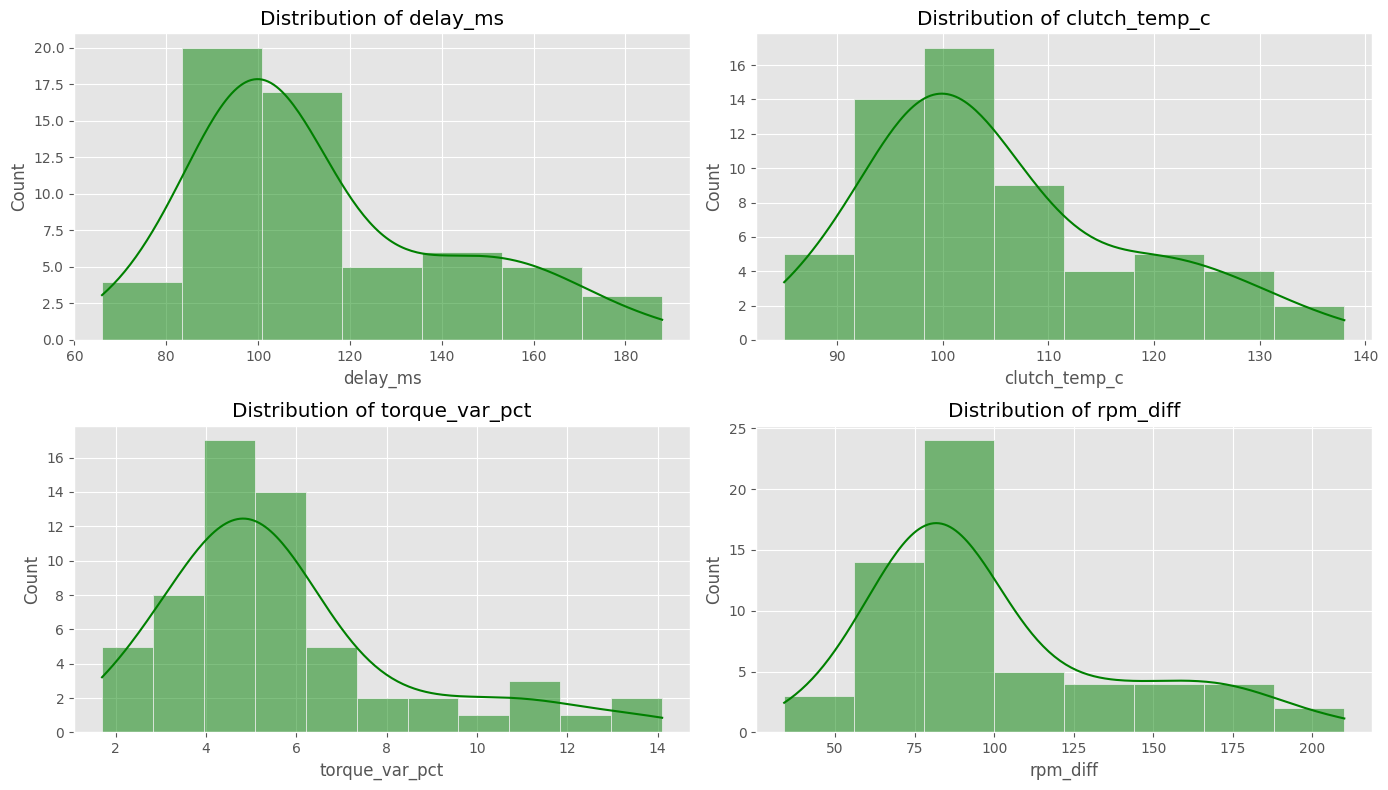

In [10]:
# Prepare the plot the distributions for the features
numeric_cols = ["delay_ms", "clutch_temp_c", "torque_var_pct", "rpm_diff"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot distribution for each feature
for i, col in enumerate(numeric_cols):
    row = i // 2
    col_pos = i % 2
    sns.histplot(df[col], kde=True, ax=axes[row, col_pos], color="green")
    axes[row, col_pos].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

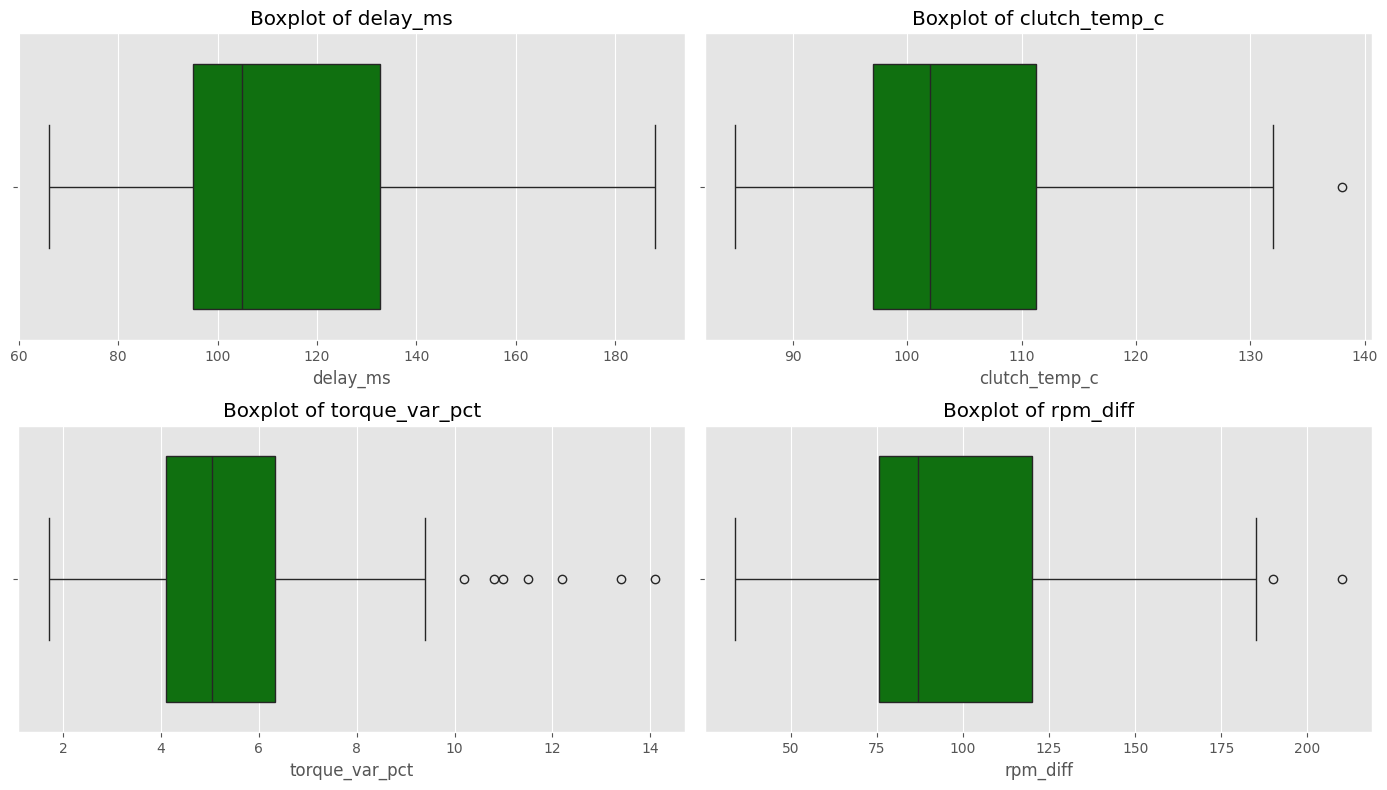

In [11]:
# Prepare to plot boxplots for all features
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Loop through each feature and draw boxplot
for i, col in enumerate(numeric_cols):
    row = i // 2
    col_pos = i % 2
    sns.boxplot(x=df[col], ax=axes[row, col_pos], color="green")
    axes[row, col_pos].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

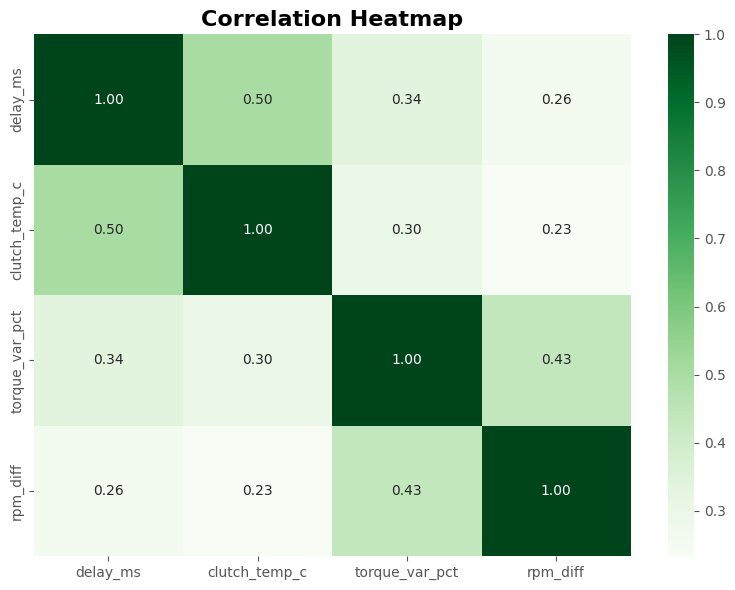

In [12]:
# Prepare correlation heatmap
plt.figure(figsize=(8,6))

# Get correlation values for the features
corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Greens",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

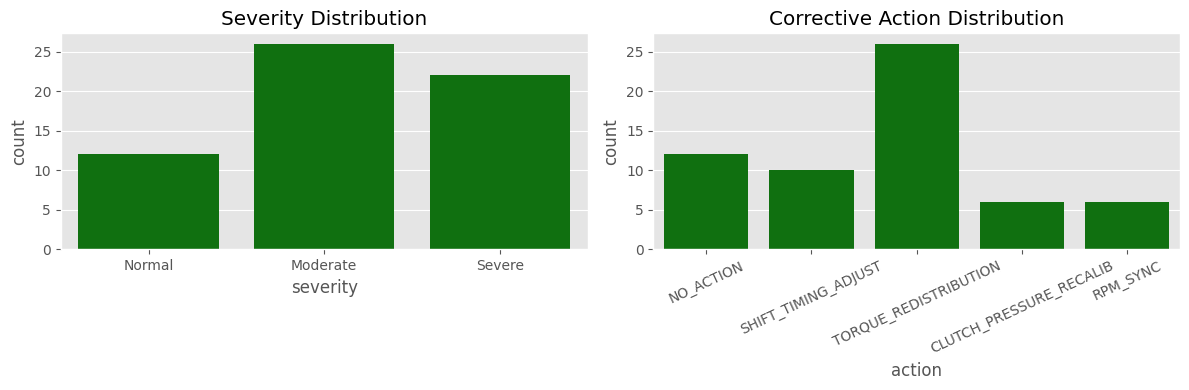

In [13]:
# Prepare to plot class distributions for severity and action
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Severity distribution
sns.countplot(data=df, x="severity", ax=axes[0], color="green")
axes[0].set_title("Severity Distribution")

# Action distribution
sns.countplot(data=df, x="action", ax=axes[1], color="green")
axes[1].set_title("Corrective Action Distribution")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

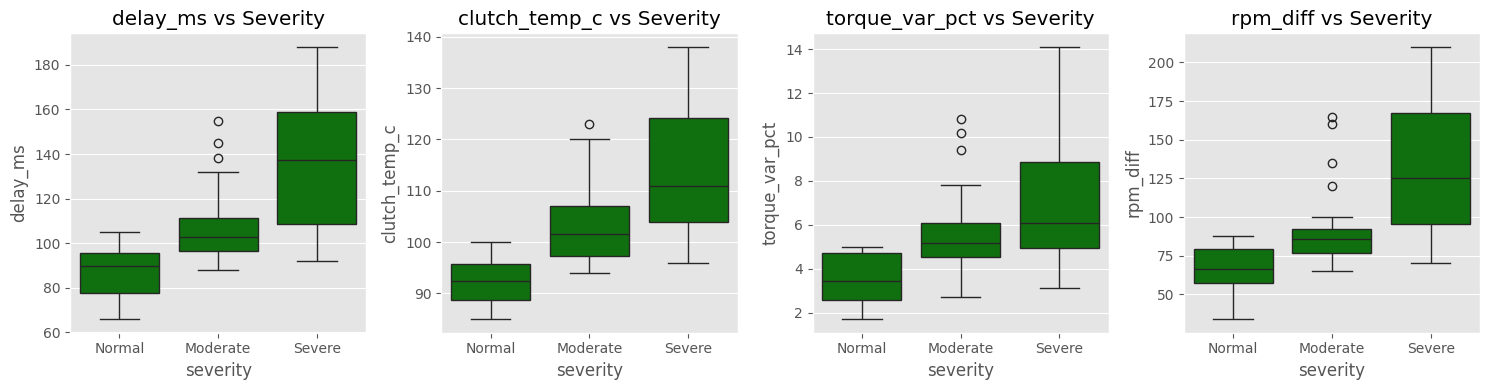

In [16]:
# Boxplot of distirbutions by severity
features = ["delay_ms", "clutch_temp_c", "torque_var_pct", "rpm_diff"]

fig, axes = plt.subplots(1, 4, figsize=(15,4))

for i, col in enumerate(features):
    sns.boxplot(data=df, x="severity", y=col, ax=axes[i], color="green")
    axes[i].set_title(f"{col} vs Severity")

plt.tight_layout()
plt.show()

# 3. Data Preprocessing and Splitting

In [ ]:
# Required input features
features = ["delay_ms", "clutch_temp_c", "torque_var_pct", "rpm_diff"]

In [ ]:
# Perform outlier handling
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Remove outliers
    df[col] = df[col].clip(lower, upper)

In [ ]:
X = df[features]

In [ ]:
# Target variables
y_sev = df["severity"]
y_act = df["action"]

In [ ]:
# Encode variables
le_sev_encoder = LabelEncoder()
le_act_encoder = LabelEncoder()

y_sev_encoded = le_sev_encoder.fit_transform(y_sev)
y_act_encoded = le_act_encoder.fit_transform(y_act)

In [ ]:
# Perform train-test splitting
X_train, X_test, y_sev_train, y_sev_test, y_act_train, y_act_test = train_test_split(
    X,
    y_sev_encoded,
    y_act_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_sev_encoded
)

# 4. Model Training and Selection

## 4.1 Random Forest

In [ ]:
# Build models with balanced class weighting
sev_rf = RandomForestClassifier(random_state=42, class_weight="balanced")
act_rf = RandomForestClassifier(random_state=42, class_weight="balanced")

In [ ]:
sev_rf.fit(X_train, y_sev_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
act_rf.fit(X_train, y_act_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
def evaluate_model(model, X_test, y_test, target_names) -> None:
  """
  Evaluates a machine learning model using a classification
  report and a confusion matrix.

  Args:
    model: The machine learning model to evaluate.
    X_test: The test data.
    y_test: The true labels for the test data.
    target_names: The names of the classes.

  Returns:
    None
  """
  # Get the predictions
  pred = model.predict(X_test)

  labels = np.arange(len(target_names))

  # Classification report
  print(classification_report(y_test, pred, labels=labels, target_names=target_names, zero_division=0))

  # Confusion matrix
  cm = confusion_matrix(y_test, pred, labels=labels)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
  disp.plot(cmap=plt.cm.Blues)
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix")
  plt.tight_layout()
  plt.show()

In [ ]:
def cross_validate(model, X, y, cv, scoring) -> float:
  """
  Performs cross-validation on a machine learning model.

  Args:
    model: The machine learning model to evaluate.
    X: The input features.
    y: The target variable.
    cv: The cross-validation object.
    scoring: The scoring metric.

  Returns:
    float: The mean score of the cross-validation.
  """
  # Cross-validate models
  scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
  mean_score = scores.mean()

  # Display scores
  print(f"{scoring} scores:", scores)
  print(f"Mean {scoring}:", mean_score)

  return mean_score

In [ ]:
def measure_inference_time(sev_model, act_model, X_sample, repeat=1000) -> float:
  """
  Measures the inference time of a machine learning model.

  Args:
    sev_model: The severity model to evaluate.
    act_model: The action model to evaluate.
    X_sample: A sample of the input data.

  Returns:
    float: The inference time in seconds.
  """

  total_time = 0

  # Loop through `repeat` number of times.
  for _ in range(repeat):

      # Sample a record
      sample = X_sample.sample(1)

      start = time.perf_counter()

      # Let both models predict this sample
      sev_model.predict(sample)
      act_model.predict(sample)

      end = time.perf_counter()

      # Increment total time
      total_time += (end - start)

  avg_time = total_time / repeat

  return avg_time

In [ ]:
# Stratified cross-validation was used to preserve the class distribution
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

              precision    recall  f1-score   support

    Moderate       0.57      0.80      0.67         5
      Normal       1.00      1.00      1.00         2
      Severe       0.67      0.40      0.50         5

    accuracy                           0.67        12
   macro avg       0.75      0.73      0.72        12
weighted avg       0.68      0.67      0.65        12



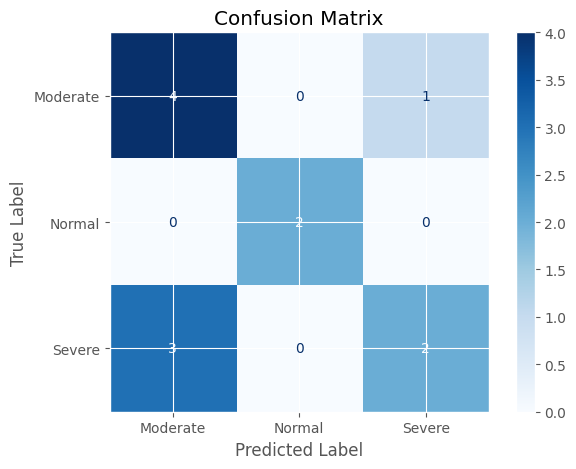

In [ ]:
# Evaluate severity random forest model
evaluate_model(sev_rf, X_test, y_sev_test, le_sev_encoder.classes_)

                         precision    recall  f1-score   support

CLUTCH_PRESSURE_RECALIB       0.00      0.00      0.00         0
              NO_ACTION       1.00      1.00      1.00         2
               RPM_SYNC       1.00      1.00      1.00         2
    SHIFT_TIMING_ADJUST       1.00      1.00      1.00         1
  TORQUE_REDISTRIBUTION       1.00      1.00      1.00         7

               accuracy                           1.00        12
              macro avg       0.80      0.80      0.80        12
           weighted avg       1.00      1.00      1.00        12



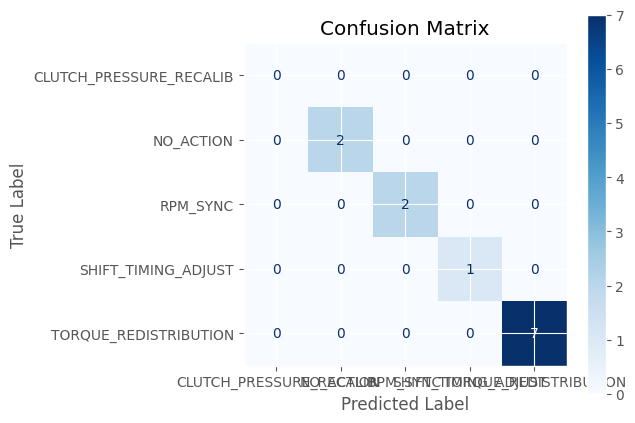

In [ ]:
# Evaluate action random forest model
evaluate_model(act_rf, X_test, y_act_test, le_act_encoder.classes_)

In [ ]:
# Calculate severity mean score for severity random forest
sev_rf_mean_score = cross_validate(sev_rf, X, y_sev_encoded, cv, "accuracy")

accuracy scores: [0.66666667 0.75       0.66666667 0.66666667 0.66666667]
Mean accuracy: 0.6833333333333332


In [ ]:
# Calculate severity f1 score for severity random forest
sev_rf_f1 = cross_validate(sev_rf, X, y_sev_encoded, cv, "f1_weighted")

f1_weighted scores: [0.64484127 0.73122711 0.63492063 0.66111111 0.66111111]
Mean f1_weighted: 0.6666422466422466


In [ ]:
# Calculate action accuracy mean score for random forest
act_rf_mean_score = cross_validate(act_rf, X, y_act_encoded, cv, "accuracy")

accuracy scores: [0.75       0.58333333 1.         0.91666667 0.91666667]
Mean accuracy: 0.8333333333333334


In [ ]:
# Calculate action f1 score for random forest
act_rf_f1 = cross_validate(act_rf, X, y_act_encoded, cv, "f1_weighted")

f1_weighted scores: [0.73636364 0.56060606 1.         0.91666667 0.90656566]
Mean f1_weighted: 0.8240404040404041


In [ ]:
# Calculate inference time
rf_inference = measure_inference_time(sev_rf, act_rf, X_test)

In [ ]:
print(f"Inference time (Random Forest): {rf_inference:.3f}")

Inference time (Random Forest): 0.018


## 4.2 Decision Tree

In [ ]:
# Create balanced decision trees
sev_dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
act_dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")

In [ ]:
sev_dt.fit(X_train, y_sev_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
act_dt.fit(X_train, y_act_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

                         precision    recall  f1-score   support

CLUTCH_PRESSURE_RECALIB       0.00      0.00      0.00         0
              NO_ACTION       1.00      1.00      1.00         2
               RPM_SYNC       1.00      1.00      1.00         2
    SHIFT_TIMING_ADJUST       1.00      1.00      1.00         1
  TORQUE_REDISTRIBUTION       1.00      1.00      1.00         7

               accuracy                           1.00        12
              macro avg       0.80      0.80      0.80        12
           weighted avg       1.00      1.00      1.00        12



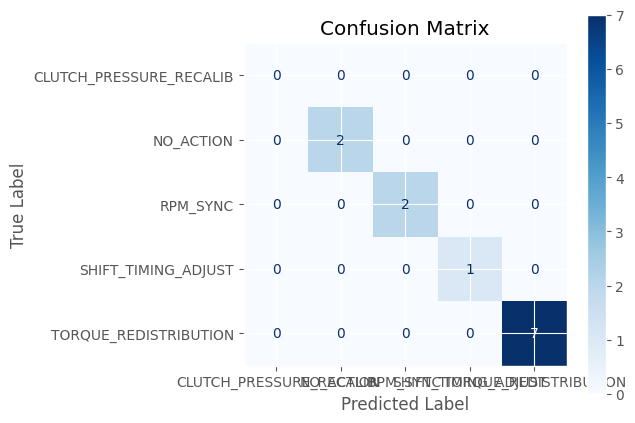

In [ ]:
# Evaluate action decision tree
evaluate_model(act_dt, X_test, y_act_test, le_act_encoder.classes_)

              precision    recall  f1-score   support

    Moderate       0.50      0.60      0.55         5
      Normal       1.00      1.00      1.00         2
      Severe       0.50      0.40      0.44         5

    accuracy                           0.58        12
   macro avg       0.67      0.67      0.66        12
weighted avg       0.58      0.58      0.58        12



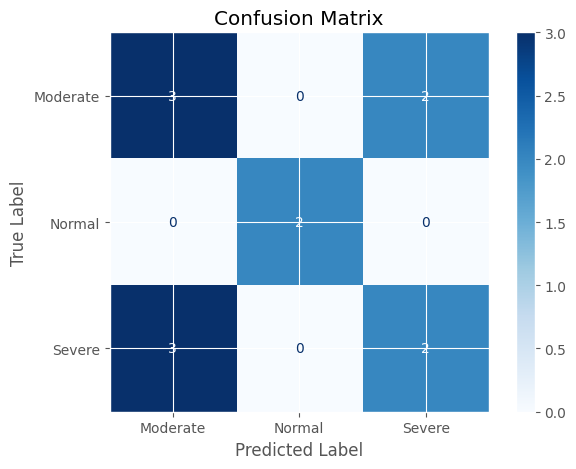

In [ ]:
# Evaluate severity decision tree
evaluate_model(sev_dt, X_test, y_sev_test, le_sev_encoder.classes_)

In [ ]:
# Severity decision tree mean accuracy score
sev_dt_mean_score = cross_validate(sev_dt, X, y_sev_encoded, cv, "accuracy")

accuracy scores: [0.66666667 0.83333333 0.83333333 0.58333333 0.75      ]
Mean accuracy: 0.7333333333333334


In [ ]:
# Severity decision tree f1 weighted score
sev_dt_f1 = cross_validate(sev_dt, X, y_sev_encoded, cv, "f1_weighted")

f1_weighted scores: [0.64273504 0.80555556 0.83333333 0.57407407 0.74444444]
Mean f1_weighted: 0.7200284900284901


In [ ]:
# Action decision tree mean accuracy score
act_dt_mean_score = cross_validate(act_dt, X, y_act_encoded, cv, "accuracy")

accuracy scores: [0.58333333 0.5        1.         0.91666667 0.91666667]
Mean accuracy: 0.7833333333333333


In [ ]:
# Action decision tree f1 weighted score
act_dt_f1 = cross_validate(act_dt, X, y_act_encoded, cv, "f1_weighted")

f1_weighted scores: [0.58994709 0.48809524 1.         0.91666667 0.90656566]
Mean f1_weighted: 0.7802549302549303


In [ ]:
# Measure the inference time for the decision tree
dt_inference = measure_inference_time(sev_dt, act_dt, X_test)

In [ ]:
print(f"Inference time (Decision Tree): {dt_inference:.3f}")

Inference time (Decision Tree): 0.002


## 4.3 K-Nearest Neighbours

In [ ]:
# Use pipeline for easy model building and scaling due to different ranges of values
sev_knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

In [ ]:
act_knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

In [ ]:
# Train KNN severity model
sev_knn_pipeline.fit(X_train, y_sev_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [ ]:
# Train KNN action model
act_knn_pipeline.fit(X_train, y_act_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

              precision    recall  f1-score   support

    Moderate       0.62      1.00      0.77         5
      Normal       1.00      1.00      1.00         2
      Severe       1.00      0.40      0.57         5

    accuracy                           0.75        12
   macro avg       0.88      0.80      0.78        12
weighted avg       0.84      0.75      0.73        12



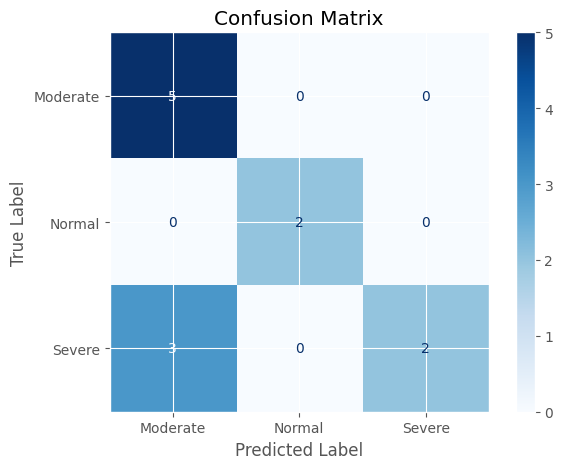

In [ ]:
# Evaluate KNN severity model
evaluate_model(sev_knn_pipeline, X_test, y_sev_test, le_sev_encoder.classes_)

                         precision    recall  f1-score   support

CLUTCH_PRESSURE_RECALIB       0.00      0.00      0.00         0
              NO_ACTION       0.67      1.00      0.80         2
               RPM_SYNC       1.00      1.00      1.00         2
    SHIFT_TIMING_ADJUST       1.00      1.00      1.00         1
  TORQUE_REDISTRIBUTION       1.00      0.71      0.83         7

               accuracy                           0.83        12
              macro avg       0.73      0.74      0.73        12
           weighted avg       0.94      0.83      0.87        12



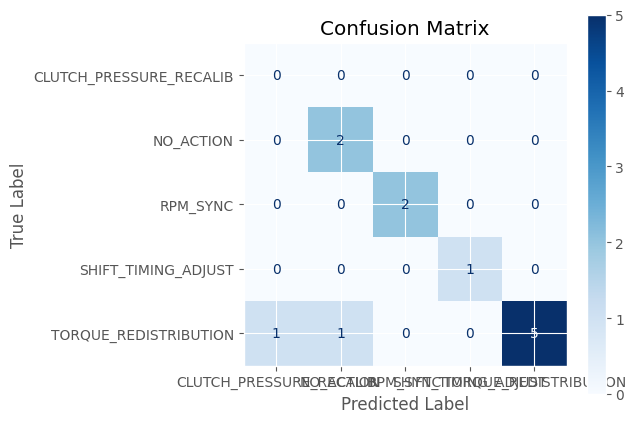

In [ ]:
# Evaluate KNN action model
evaluate_model(act_knn_pipeline, X_test, y_act_test, le_act_encoder.classes_)

In [ ]:
# Severity KNN accuracy mean score
sev_knn_mean_score = cross_validate(sev_knn_pipeline, X, y_sev_encoded, cv, "accuracy")

accuracy scores: [0.91666667 0.75       0.75       0.58333333 0.83333333]
Mean accuracy: 0.7666666666666667


In [ ]:
# Severity KNN f1-score
sev_knn_f1 = cross_validate(sev_knn_pipeline, X, y_sev_encoded, cv, "f1_weighted")

f1_weighted scores: [0.91450216 0.7530303  0.74017094 0.57275132 0.83333333]
Mean f1_weighted: 0.7627576127576128


In [ ]:
# Action KNN mean accuracy score
act_knn_mean_score = cross_validate(act_knn_pipeline, X, y_act_encoded, cv, "accuracy")

accuracy scores: [0.83333333 0.66666667 0.83333333 0.66666667 0.75      ]
Mean accuracy: 0.75


In [ ]:
# Action KNN f1-score
act_knn_f1 = cross_validate(act_knn_pipeline, X, y_act_encoded, cv, "f1_weighted")

f1_weighted scores: [0.78751804 0.63888889 0.83888889 0.62247475 0.74444444]
Mean f1_weighted: 0.7264430014430014


In [ ]:
# KNN inference
knn_inference = measure_inference_time(sev_knn_pipeline, act_knn_pipeline, X_test)

In [ ]:
print(f"Inference time (K-Nearest Neighbors): {knn_inference:.3f}")

Inference time (K-Nearest Neighbors): 0.006


## 4.4 Support Vector Machine (SVM)

In [ ]:
# Scale for SVM
sev_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(class_weight="balanced"))
])

In [ ]:
act_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(class_weight="balanced"))
])

In [ ]:
sev_svm_pipeline.fit(X_train, y_sev_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(class_weight='balanced'))])

In [ ]:
act_svm_pipeline.fit(X_train, y_act_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(class_weight='balanced'))])

              precision    recall  f1-score   support

    Moderate       1.00      0.80      0.89         5
      Normal       1.00      1.00      1.00         2
      Severe       0.83      1.00      0.91         5

    accuracy                           0.92        12
   macro avg       0.94      0.93      0.93        12
weighted avg       0.93      0.92      0.92        12



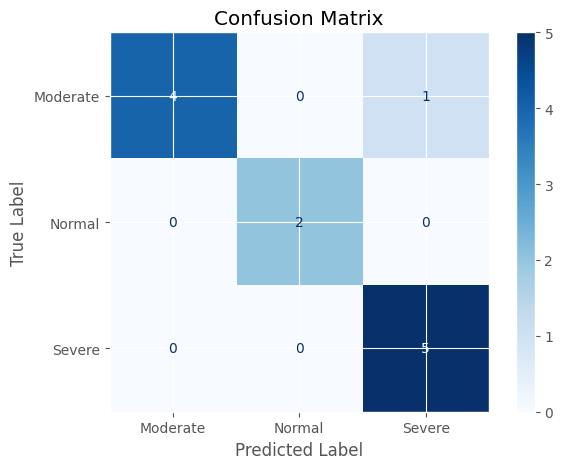

In [ ]:
# Evaluate severity SVM
evaluate_model(sev_svm_pipeline, X_test, y_sev_test, le_sev_encoder.classes_)

                         precision    recall  f1-score   support

CLUTCH_PRESSURE_RECALIB       0.00      0.00      0.00         0
              NO_ACTION       1.00      1.00      1.00         2
               RPM_SYNC       1.00      1.00      1.00         2
    SHIFT_TIMING_ADJUST       1.00      1.00      1.00         1
  TORQUE_REDISTRIBUTION       1.00      0.86      0.92         7

               accuracy                           0.92        12
              macro avg       0.80      0.77      0.78        12
           weighted avg       1.00      0.92      0.96        12



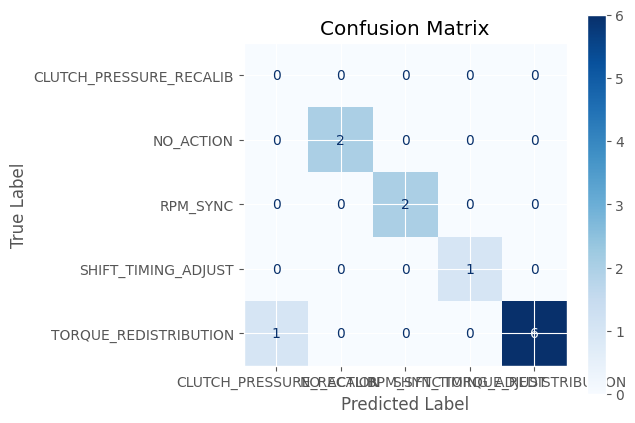

In [ ]:
# Evaluate action SVM
evaluate_model(act_svm_pipeline, X_test, y_act_test, le_act_encoder.classes_)

In [ ]:
# Calculate severity SVM mean accuracy score
sev_svm_mean_score = cross_validate(sev_svm_pipeline, X, y_sev_encoded, cv, "accuracy")

accuracy scores: [0.83333333 0.83333333 0.91666667 0.58333333 0.75      ]
Mean accuracy: 0.7833333333333334


In [ ]:
# Calculate severity SVM f1-score
sev_svm_f1 = cross_validate(sev_svm_pipeline, X, y_sev_encoded, cv, "f1_weighted")

f1_weighted scores: [0.80555556 0.82962963 0.91750842 0.54761905 0.74747475]
Mean f1_weighted: 0.7695574795574796


In [ ]:
# Calculate action SVM mean score
act_svm_mean_score = cross_validate(act_svm_pipeline, X, y_act_encoded, cv, "accuracy")

accuracy scores: [0.91666667 0.75       0.75       0.75       0.75      ]
Mean accuracy: 0.7833333333333333


In [ ]:
# Calculate action SVM f1-score
act_svm_f1 = cross_validate(act_svm_pipeline, X, y_act_encoded, cv, "f1_weighted")

f1_weighted scores: [0.87878788 0.71969697 0.78333333 0.79027778 0.76388889]
Mean f1_weighted: 0.7871969696969697


In [ ]:
# SVM inference
svm_inference = measure_inference_time(sev_svm_pipeline, act_svm_pipeline, X_test)

In [ ]:
print(f"Inference time (SVM): {svm_inference:.3f}")

Inference time (SVM): 0.004


## 4.5 Logistic Regression

In [ ]:
# Scale for Logistic Regression
sev_lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", random_state=42))
])

In [ ]:
act_lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", random_state=42))
])

In [ ]:
sev_lr_pipeline.fit(X_train, y_sev_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [ ]:
act_lr_pipeline.fit(X_train, y_act_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

              precision    recall  f1-score   support

    Moderate       0.83      1.00      0.91         5
      Normal       1.00      1.00      1.00         2
      Severe       1.00      0.80      0.89         5

    accuracy                           0.92        12
   macro avg       0.94      0.93      0.93        12
weighted avg       0.93      0.92      0.92        12



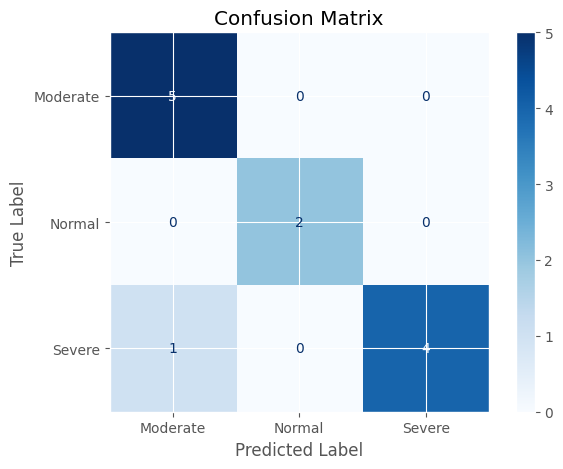

In [ ]:
# Evaluate severity LR
evaluate_model(sev_lr_pipeline, X_test, y_sev_test, le_sev_encoder.classes_)

                         precision    recall  f1-score   support

CLUTCH_PRESSURE_RECALIB       0.00      0.00      0.00         0
              NO_ACTION       1.00      1.00      1.00         2
               RPM_SYNC       0.67      1.00      0.80         2
    SHIFT_TIMING_ADJUST       1.00      1.00      1.00         1
  TORQUE_REDISTRIBUTION       1.00      0.71      0.83         7

               accuracy                           0.83        12
              macro avg       0.73      0.74      0.73        12
           weighted avg       0.94      0.83      0.87        12



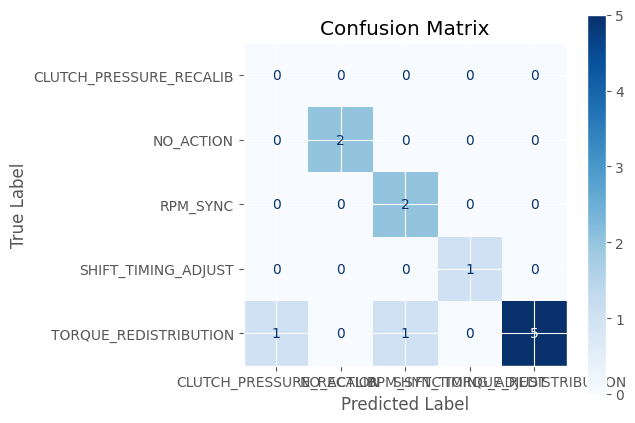

In [ ]:
# Evaluate action LR
evaluate_model(act_lr_pipeline, X_test, y_act_test, le_act_encoder.classes_)

In [ ]:
# Severity LR mean accuracy score
sev_lr_mean_score = cross_validate(sev_lr_pipeline, X, y_sev_encoded, cv, "accuracy")

accuracy scores: [0.91666667 0.83333333 0.75       0.58333333 0.75      ]
Mean accuracy: 0.7666666666666667


In [ ]:
# Severity LR f1-score
sev_lr_f1 = cross_validate(sev_lr_pipeline, X, y_sev_encoded, cv, "f1_weighted")

f1_weighted scores: [0.91212121 0.83293651 0.74175824 0.54761905 0.74444444]
Mean f1_weighted: 0.7557758907758908


In [ ]:
# Action LR mean accuracy score
act_lr_mean_score = cross_validate(act_lr_pipeline, X, y_act_encoded, cv, "accuracy")

accuracy scores: [0.91666667 0.66666667 0.83333333 0.66666667 0.91666667]
Mean accuracy: 0.7999999999999999


In [ ]:
# Action LR f1-score
act_lr_f1 = cross_validate(act_lr_pipeline, X, y_act_encoded, cv, "f1_weighted")

f1_weighted scores: [0.91798942 0.63888889 0.84444444 0.68253968 0.92592593]
Mean f1_weighted: 0.8019576719576719


In [ ]:
# LR inference time
lr_inference = measure_inference_time(sev_lr_pipeline, act_lr_pipeline, X_test)

In [ ]:
print(f"Inference time (Logistic Regression): {lr_inference:.3f}")

Inference time (Logistic Regression): 0.003


# 5. Model Comparisons

In [ ]:
# Create a dataframe for severity, action CV accuracy, with the inference time
comparisons_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "K-Nearest Neighbors",
        "Support Vector Machine",
        "Logistic Regression"
    ],

    "Severity CV Accuracy": [
        sev_rf_mean_score,
        sev_dt_mean_score,
        sev_knn_mean_score,
        sev_svm_mean_score,
        sev_lr_mean_score
    ],

    "Action CV Accuracy": [
        act_rf_mean_score,
        act_dt_mean_score,
        act_knn_mean_score,
        act_svm_mean_score,
        act_lr_mean_score
    ],

    "Inference Time": [
        np.round(rf_inference, 3),
        np.round(dt_inference, 3),
        np.round(knn_inference, 3),
        np.round(svm_inference, 3),
        np.round(lr_inference, 3)
    ],

    "Severity CV F1 Score": [
        np.round(sev_rf_f1, 3),
        np.round(sev_dt_f1, 3),
        np.round(sev_knn_f1, 3),
        np.round(sev_svm_f1, 3),
        np.round(sev_lr_f1, 3)
    ],

    "Action CV F1 Score": [
        np.round(act_rf_f1, 3),
        np.round(act_dt_f1, 3),
        np.round(act_knn_f1, 3),
        np.round(act_svm_f1, 3),
        np.round(act_lr_f1, 3)
    ]
})

In [ ]:
comparisons_df

,Model,Severity CV Accuracy,Action CV Accuracy,Inference Time,Severity CV F1 Score,Action CV F1 Score
0,Random Forest,0.683333,0.833333,0.018,0.667,0.824
1,Decision Tree,0.733333,0.783333,0.002,0.720,0.780
2,K-Nearest Neighbors,0.766667,0.750000,0.006,0.763,0.726
3,Support Vector Machine,0.783333,0.783333,0.004,0.770,0.787
4,Logistic Regression,0.766667,0.800000,0.003,0.756,0.802
